# YCSB Benchmark Visualization

Notebook tạo toàn bộ biểu đồ cho báo cáo từ 2 file CSV (`summary_mean.csv`, `summary_raw.csv`) và các log fault/load trong `analysis/results/`.

**Cách chạy:** mở từ thư mục gốc repo `ycsb-benchmark` (hoặc từ `analysis/notebooks/`), Run All. Ảnh lưu vào `analysis/results/figures/` dưới dạng `.png` (300 DPI) + `.svg`.

**6 biểu đồ tạo ra:**
1. `01_throughput` — so sánh throughput 3 DB × 4 workload (có error bar)
2. `02_read_latency` — read latency p95 & p99
3. `03_update_latency_p99` — update latency p99 (workload A/B/F, bỏ C vì 100% read)
4. `04_fault_tolerance` — timeline chịu lỗi, **3 subplot riêng**, đánh dấu UPDATE-FAILED của CockroachDB
5. `05_load_insert_latency` — hiệu năng ghi thuần lúc load 1M records
6. `06_throughput_stability` — độ ổn định (CV%) qua 3 lần chạy

In [1]:
from pathlib import Path
from datetime import datetime
import re

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import Image, display

# Notebook duoc thiet ke de chay tu root project ycsb-benchmark.
# Neu VS Code/Jupyter dat cwd la analysis/notebooks, dong if nay dua ve root project.
PROJECT_DIR = Path.cwd().resolve()
if PROJECT_DIR.name == "notebooks" and PROJECT_DIR.parent.name == "analysis":
    PROJECT_DIR = PROJECT_DIR.parent.parent

RESULTS_DIR = PROJECT_DIR / "analysis" / "results"
SUMMARY_DIR = RESULTS_DIR / "summary"
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if not (SUMMARY_DIR / "summary_mean.csv").exists():
    raise FileNotFoundError(f"Khong tim thay summary CSV tai: {SUMMARY_DIR}")

DB_ORDER = ["mongodb", "cassandra", "cockroachdb"]
DB_LABELS = {
    "mongodb": "MongoDB",
    "cassandra": "Cassandra",
    "cockroachdb": "CockroachDB",
}
DB_COLORS = {
    "mongodb": "#009E73",
    "cassandra": "#0072B2",
    "cockroachdb": "#E69F00",
}

WORKLOAD_ORDER = ["a", "b", "c", "f"]
WORKLOAD_LABELS = {
    "a": "A\n(50R/50U)",
    "b": "B\n(95R/5U)",
    "c": "C\n(100R)",
    "f": "F\n(50R/50RMW)",
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "figure.titlesize": 14,
    "legend.frameon": False,
    "savefig.dpi": 300,
    "svg.fonttype": "none",
})

print("Project:", PROJECT_DIR)
print("Figures:", FIGURES_DIR)


Project: D:\UIT\Projects\ycsb-benchmark
Figures: D:\UIT\Projects\ycsb-benchmark\analysis\results\figures


## Load Summary CSV


In [2]:
mean_df = pd.read_csv(SUMMARY_DIR / "summary_mean.csv")
raw_df = pd.read_csv(SUMMARY_DIR / "summary_raw.csv")

for frame in (mean_df, raw_df):
    frame["db"] = pd.Categorical(frame["db"], categories=DB_ORDER, ordered=True)
    frame["workload"] = pd.Categorical(frame["workload"], categories=WORKLOAD_ORDER, ordered=True)
    frame.sort_values(["workload", "db"], inplace=True)

print(f"summary_mean.csv: {len(mean_df)} rows")
print(f"summary_raw.csv:  {len(raw_df)} rows")
display(mean_df[[
    "db", "workload", "throughput_ops_sec", "throughput_std",
    "read_p95_us", "read_p99_us", "update_p99_us"
]])


summary_mean.csv: 12 rows
summary_raw.csv:  36 rows


,db,workload,throughput_ops_sec,throughput_std,read_p95_us,read_p99_us,update_p99_us
8,mongodb,a,941.82,58.93,4885.67,18399.00,133759.00
0,cassandra,a,4010.62,76.12,11671.00,33193.67,25620.33
4,cockroachdb,a,1019.33,21.50,17524.33,25972.33,124201.67
9,mongodb,b,3822.53,196.66,5305.67,48511.00,142249.67
1,cassandra,b,3418.69,393.70,12489.67,31775.00,26105.67
5,cockroachdb,b,2514.14,47.03,11697.67,17844.33,120767.00
10,mongodb,c,6405.01,122.14,3179.67,65055.00,NaN
2,cassandra,c,3347.35,431.67,11391.00,32692.33,NaN
6,cockroachdb,c,3841.68,83.75,8233.67,12505.67,NaN
11,mongodb,f,892.47,20.27,5172.33,20103.00,145065.67


## Helper Functions


In [3]:
def save_figure(fig, stem):
    fig.savefig(FIGURES_DIR / f"{stem}.png", bbox_inches="tight")
    fig.savefig(FIGURES_DIR / f"{stem}.svg", bbox_inches="tight")
    print(f"saved {stem}.png / {stem}.svg")


def db_slice(df, db):
    return df[df["db"].astype(str) == db].set_index("workload")


def format_ops(axis):
    axis.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))


def finish_axis(ax, grid_axis="y"):
    ax.grid(axis=grid_axis, linestyle="--", alpha=0.35)
    sns.despine(ax=ax)


## Figure 1 - Throughput


saved 01_throughput.png / 01_throughput.svg


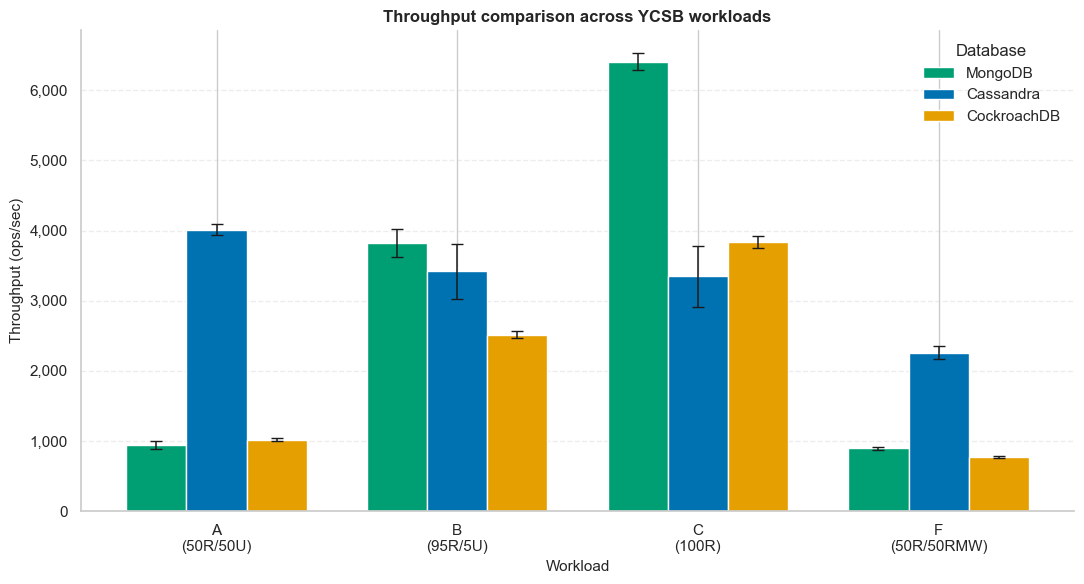

In [4]:
fig, ax = plt.subplots(figsize=(11, 6))
width = 0.25
x = list(range(len(WORKLOAD_ORDER)))

for i, db in enumerate(DB_ORDER):
    sub = db_slice(mean_df, db)
    vals = [sub.loc[w, "throughput_ops_sec"] for w in WORKLOAD_ORDER]
    errs = [sub.loc[w, "throughput_std"] for w in WORKLOAD_ORDER]
    offset = (i - 1) * width
    ax.bar(
        [xi + offset for xi in x], vals, width,
        yerr=errs, capsize=4, color=DB_COLORS[db], label=DB_LABELS[db],
        error_kw={"elinewidth": 1.1},
    )

ax.set_xticks(x)
ax.set_xticklabels([WORKLOAD_LABELS[w] for w in WORKLOAD_ORDER])
ax.set_xlabel("Workload")
ax.set_ylabel("Throughput (ops/sec)")
ax.set_title("Throughput comparison across YCSB workloads")
ax.legend(title="Database")
format_ops(ax)
finish_axis(ax)
fig.tight_layout()
save_figure(fig, "01_throughput")
plt.show()


## Figure 2 - Read Latency p95/p99


saved 02_read_latency.png / 02_read_latency.svg


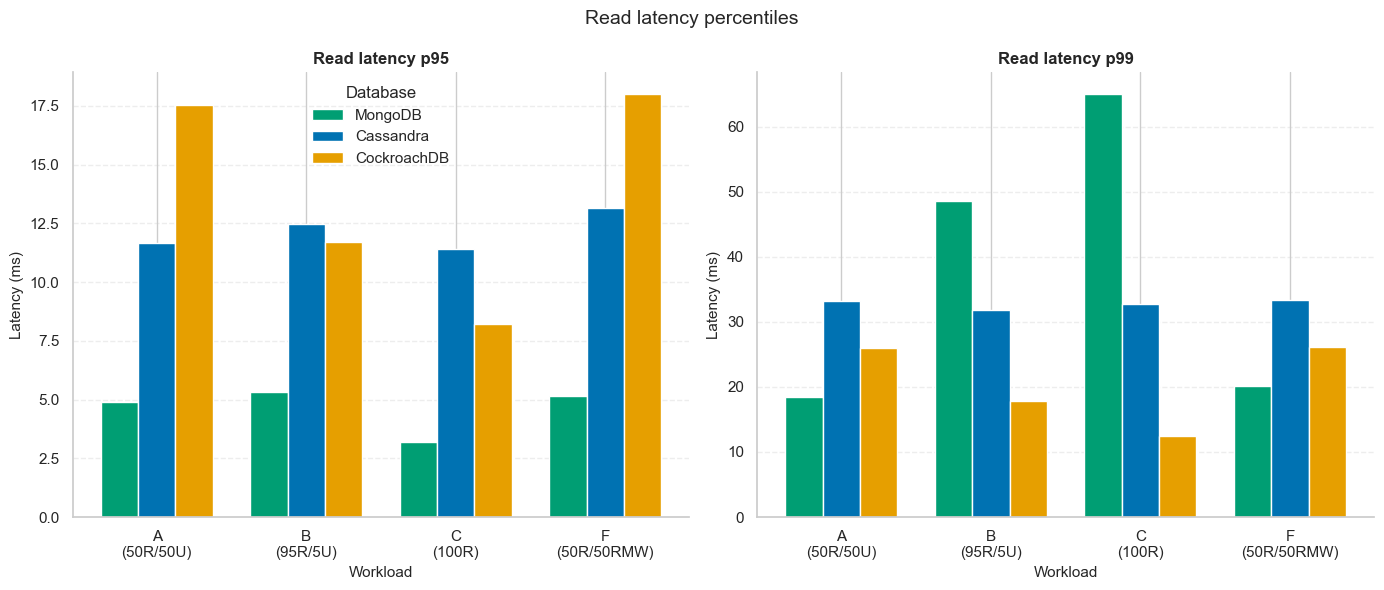

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
width = 0.25
x = list(range(len(WORKLOAD_ORDER)))

for ax, col, title in zip(
    axes,
    ["read_p95_us", "read_p99_us"],
    ["Read latency p95", "Read latency p99"],
):
    for i, db in enumerate(DB_ORDER):
        sub = db_slice(mean_df, db)
        vals = [sub.loc[w, col] / 1000 for w in WORKLOAD_ORDER]
        offset = (i - 1) * width
        ax.bar([xi + offset for xi in x], vals, width, color=DB_COLORS[db], label=DB_LABELS[db])
    ax.set_xticks(x)
    ax.set_xticklabels([WORKLOAD_LABELS[w] for w in WORKLOAD_ORDER])
    ax.set_xlabel("Workload")
    ax.set_ylabel("Latency (ms)")
    ax.set_title(title)
    finish_axis(ax)

axes[0].legend(title="Database")
fig.suptitle("Read latency percentiles")
fig.tight_layout()
save_figure(fig, "02_read_latency")
plt.show()


## Figure 3 - Update Latency p99


saved 03_update_latency_p99.png / 03_update_latency_p99.svg


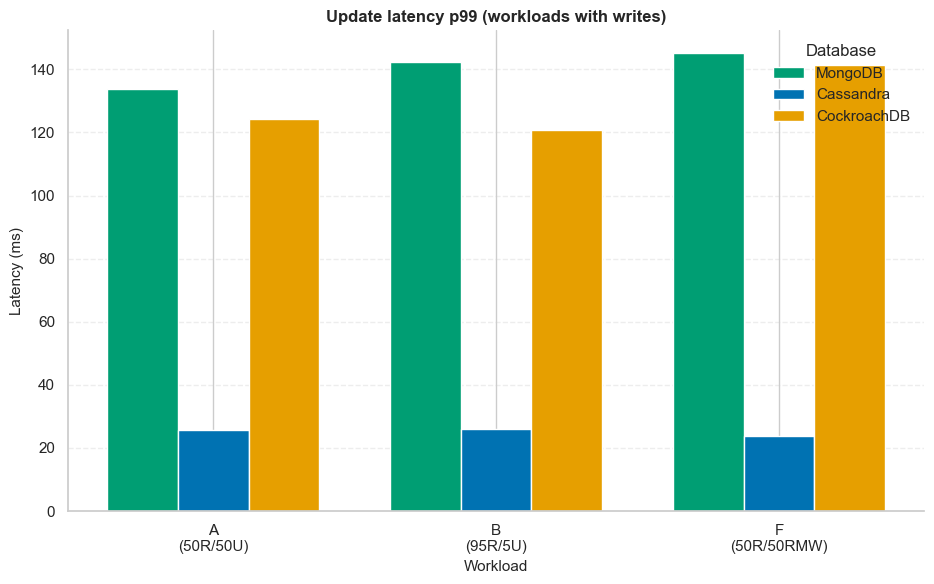

In [6]:
workloads_with_update = ["a", "b", "f"]
fig, ax = plt.subplots(figsize=(9.5, 6))
width = 0.25
x = list(range(len(workloads_with_update)))

for i, db in enumerate(DB_ORDER):
    sub = db_slice(mean_df, db)
    vals = [sub.loc[w, "update_p99_us"] / 1000 for w in workloads_with_update]
    offset = (i - 1) * width
    ax.bar([xi + offset for xi in x], vals, width, color=DB_COLORS[db], label=DB_LABELS[db])

ax.set_xticks(x)
ax.set_xticklabels([WORKLOAD_LABELS[w] for w in workloads_with_update])
ax.set_xlabel("Workload")
ax.set_ylabel("Latency (ms)")
ax.set_title("Update latency p99 (workloads with writes)")
ax.legend(title="Database")
finish_axis(ax)
fig.tight_layout()
save_figure(fig, "03_update_latency_p99")
plt.show()


## Figure 4 - Fault Tolerance Timeline

Biểu đồ này tách riêng 3 database vì timeline benchmark khác nhau. Mỗi subplot có STOP/RECOVERY riêng đọc từ `log_<db>_fault_events.txt`. Riêng CockroachDB đánh dấu điểm `UPDATE-FAILED`.


In [7]:
STATUS_RE = re.compile(r"(\d+)\s+sec:\s+(\d+)\s+operations;\s+([\d.]+)\s+current ops/sec")
FAILED_RE = re.compile(r"\[UPDATE-FAILED:\s+Count=(\d+)")
EVENT_RE = re.compile(r"^\[([\d-]+\s+[\d:]+)\]\s+(.+)$")


def parse_fault_log(db):
    path = RESULTS_DIR / db / f"log_{db}_a_fault.txt"
    if not path.exists():
        print(f"[skip] khong tim thay {path.name}")
        return pd.DataFrame(columns=["elapsed_sec", "operations", "current_ops_sec", "update_failed_count"])
    rows = []
    for line in path.read_text(encoding="utf-8", errors="replace").splitlines():
        match = STATUS_RE.search(line)
        if not match:
            continue
        failed = FAILED_RE.search(line)
        rows.append({
            "elapsed_sec": int(match.group(1)),
            "operations": int(match.group(2)),
            "current_ops_sec": float(match.group(3)),
            "update_failed_count": int(failed.group(1)) if failed else 0,
        })
    return pd.DataFrame(rows)


def parse_fault_events(db):
    path = RESULTS_DIR / db / f"log_{db}_fault_events.txt"
    if not path.exists():
        print(f"[skip] khong tim thay {path.name}")
        return {}
    timestamps = {}
    for line in path.read_text(encoding="utf-8", errors="replace").splitlines():
        match = EVENT_RE.match(line.strip())
        if not match:
            continue
        ts = datetime.strptime(match.group(1), "%Y-%m-%d %H:%M:%S")
        event = match.group(2)
        if event.startswith("START benchmark"):
            timestamps["benchmark_start"] = ts
        elif event.startswith("STOP node"):
            timestamps["node_stop"] = ts
        elif event.startswith("START node"):
            timestamps["node_recovery"] = ts
        elif event.startswith("END benchmark"):
            timestamps["benchmark_end"] = ts

    if "benchmark_start" not in timestamps:
        return {}
    start = timestamps["benchmark_start"]
    return {key: (value - start).total_seconds() for key, value in timestamps.items() if key != "benchmark_start"}


saved 04_fault_tolerance.png / 04_fault_tolerance.svg


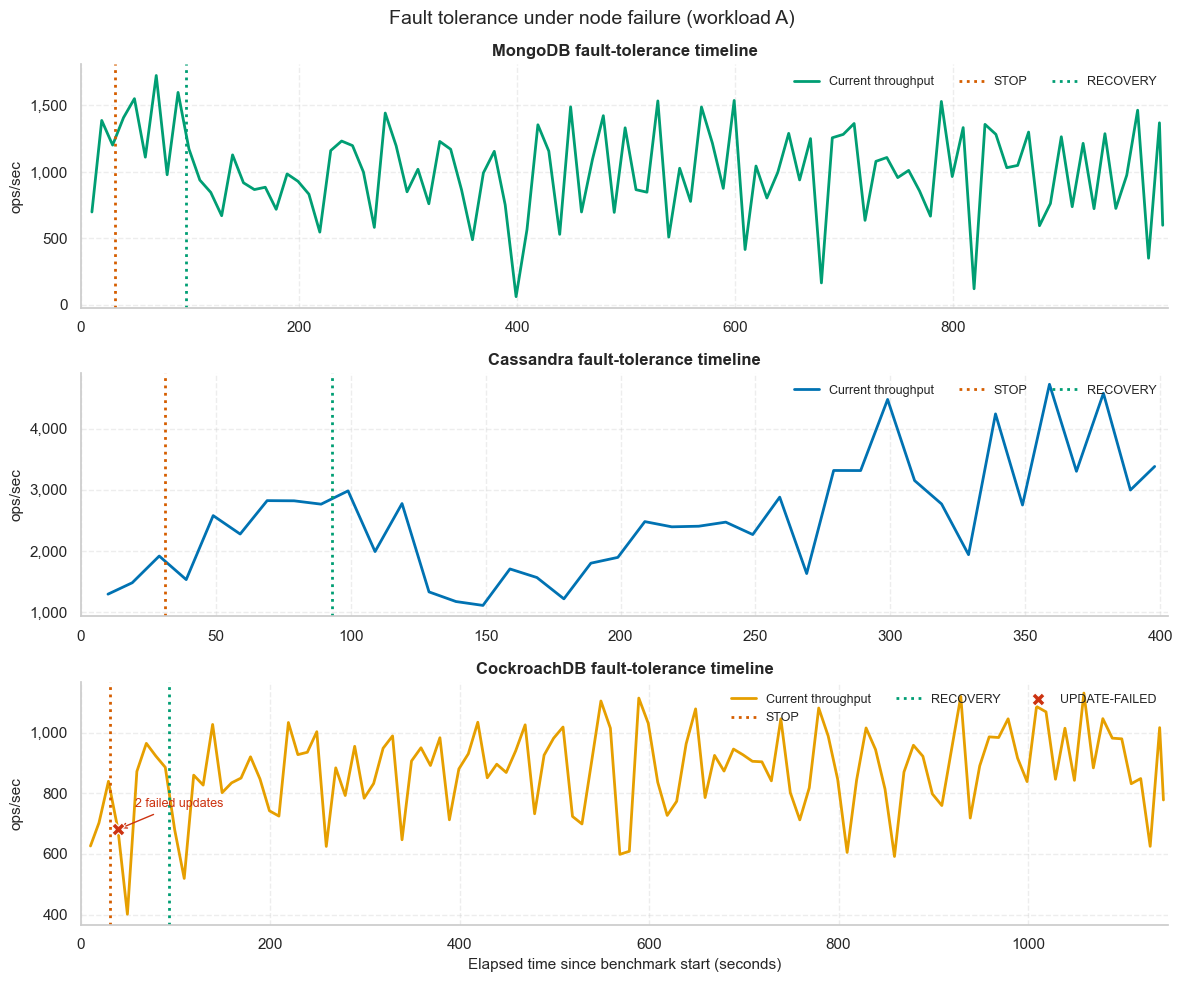

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)

for ax, db in zip(axes, DB_ORDER):
    timeline = parse_fault_log(db)
    events = parse_fault_events(db)

    if timeline.empty:
        ax.text(0.5, 0.5, f"{DB_LABELS[db]}: chua co fault log", transform=ax.transAxes,
                ha="center", va="center", fontsize=11, color="#999999")
        ax.set_title(f"{DB_LABELS[db]} fault-tolerance timeline")
        continue

    ax.plot(
        timeline["elapsed_sec"], timeline["current_ops_sec"],
        color=DB_COLORS[db], linewidth=2, label="Current throughput",
    )

    if "node_stop" in events:
        ax.axvline(events["node_stop"], color="#D55E00", linestyle=":", linewidth=2, label="STOP")
    if "node_recovery" in events:
        ax.axvline(events["node_recovery"], color="#009E73", linestyle=":", linewidth=2, label="RECOVERY")

    failed = timeline[timeline["update_failed_count"] > 0]
    if not failed.empty:
        ax.scatter(
            failed["elapsed_sec"], failed["current_ops_sec"],
            color="#CC3311", edgecolor="white", linewidth=0.8,
            s=90, marker="X", zorder=5, label="UPDATE-FAILED",
        )
        first = failed.iloc[0]
        ax.annotate(
            f"{int(first['update_failed_count'])} failed updates",
            xy=(first["elapsed_sec"], first["current_ops_sec"]),
            xytext=(12, 16), textcoords="offset points",
            arrowprops={"arrowstyle": "->", "color": "#CC3311", "lw": 1},
            fontsize=9, color="#CC3311",
        )

    ax.set_xlim(0, int(timeline["elapsed_sec"].max()) + 5)
    ax.set_ylabel("ops/sec")
    ax.set_title(f"{DB_LABELS[db]} fault-tolerance timeline")
    ax.legend(loc="upper right", ncol=3, fontsize=9)
    format_ops(ax)
    finish_axis(ax, grid_axis="both")

axes[-1].set_xlabel("Elapsed time since benchmark start (seconds)")
fig.suptitle("Fault tolerance under node failure (workload A)")
fig.tight_layout()
save_figure(fig, "04_fault_tolerance")
plt.show()


## Figure 5 - Load Phase Insert Performance


In [9]:
LOAD_METRIC_RE = re.compile(
    r"^\[(OVERALL|INSERT)\],\s+"
    r"(RunTime\(ms\)|Throughput\(ops/sec\)|Operations|AverageLatency\(us\)|"
    r"95thPercentileLatency\(us\)|99thPercentileLatency\(us\)|Return=OK),\s+([\d.]+)"
)

metric_names = {
    ("OVERALL", "RunTime(ms)"): "runtime_ms",
    ("OVERALL", "Throughput(ops/sec)"): "throughput_ops_sec",
    ("INSERT", "Operations"): "insert_ops",
    ("INSERT", "AverageLatency(us)"): "insert_avg_us",
    ("INSERT", "95thPercentileLatency(us)"): "insert_p95_us",
    ("INSERT", "99thPercentileLatency(us)"): "insert_p99_us",
    ("INSERT", "Return=OK"): "insert_ok",
}

load_rows = []
for db in DB_ORDER:
    path = RESULTS_DIR / db / f"log_{db}_load.txt"
    if not path.exists():
        print(f"[skip] khong tim thay {path.name}")
        continue
    record = {"db": db}
    for line in path.read_text(encoding="utf-8", errors="replace").splitlines():
        match = LOAD_METRIC_RE.match(line.strip())
        if match:
            record[metric_names[(match.group(1), match.group(2))]] = float(match.group(3))
    load_rows.append(record)

if load_rows:
    load_df = pd.DataFrame(load_rows).set_index("db").reindex([d for d in DB_ORDER if d in [r["db"] for r in load_rows]])
    display(load_df)
else:
    load_df = pd.DataFrame()
    print("Khong co load log nao — bo qua bieu do 05.")


,runtime_ms,throughput_ops_sec,insert_ops,insert_avg_us,insert_p95_us,insert_p99_us,insert_ok
db,,,,,,,
mongodb,951030.0,1051.491541,1000000.0,15193.010454,31871.0,61631.0,1000000.0
cassandra,253713.0,3941.461415,1000000.0,3971.991821,11375.0,37855.0,1000000.0
cockroachdb,892584.0,1120.342735,1000000.0,14259.044517,27263.0,68479.0,1000000.0


saved 05_load_insert_latency.png / 05_load_insert_latency.svg


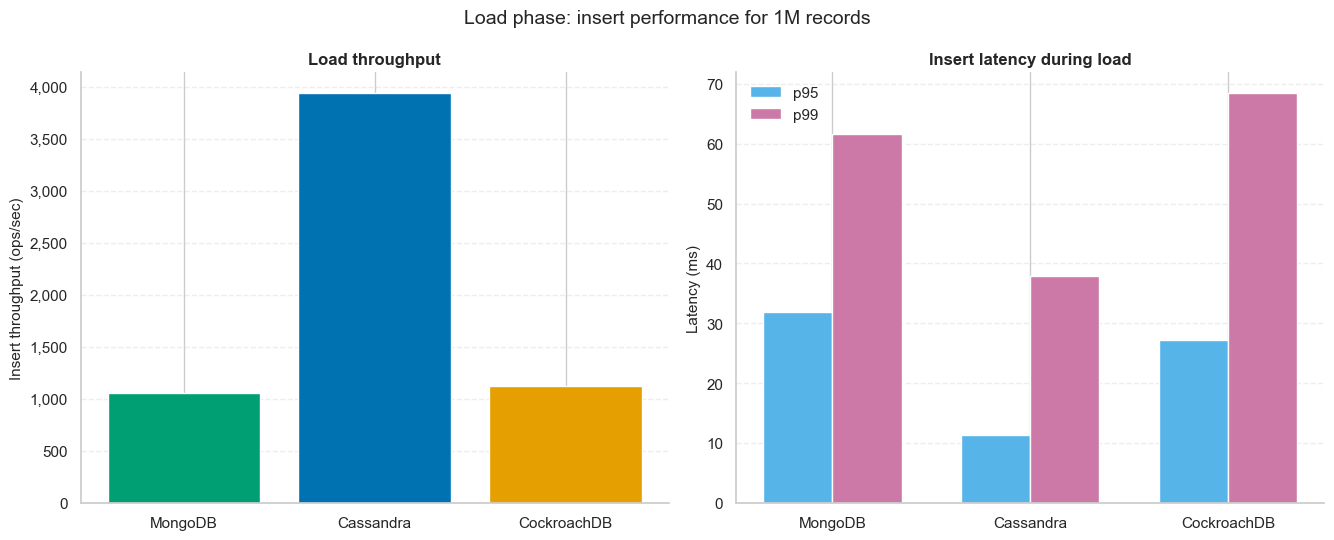

In [10]:
if load_df.empty:
    print("Bo qua bieu do 05 — chua co load log.")
else:
    present_dbs = [db for db in DB_ORDER if db in load_df.index]
    labels = [DB_LABELS[db] for db in present_dbs]
    colors = [DB_COLORS[db] for db in present_dbs]
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.5))

    axes[0].bar(labels, load_df.loc[present_dbs, "throughput_ops_sec"], color=colors)
    axes[0].set_title("Load throughput")
    axes[0].set_ylabel("Insert throughput (ops/sec)")
    format_ops(axes[0])
    finish_axis(axes[0])

    x = list(range(len(present_dbs)))
    width = 0.35
    axes[1].bar([xi - width / 2 for xi in x], load_df.loc[present_dbs, "insert_p95_us"] / 1000, width, color="#56B4E9", label="p95")
    axes[1].bar([xi + width / 2 for xi in x], load_df.loc[present_dbs, "insert_p99_us"] / 1000, width, color="#CC79A7", label="p99")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels)
    axes[1].set_title("Insert latency during load")
    axes[1].set_ylabel("Latency (ms)")
    axes[1].legend()
    finish_axis(axes[1])

    fig.suptitle("Load phase: insert performance for 1M records")
    fig.tight_layout()
    save_figure(fig, "05_load_insert_latency")
    plt.show()


## Figure 6 - Throughput Stability

CV = standard deviation / mean throughput. CV thấp hơn nghĩa là throughput ổn định hơn qua 3 lần chạy.


saved 06_throughput_stability.png / 06_throughput_stability.svg


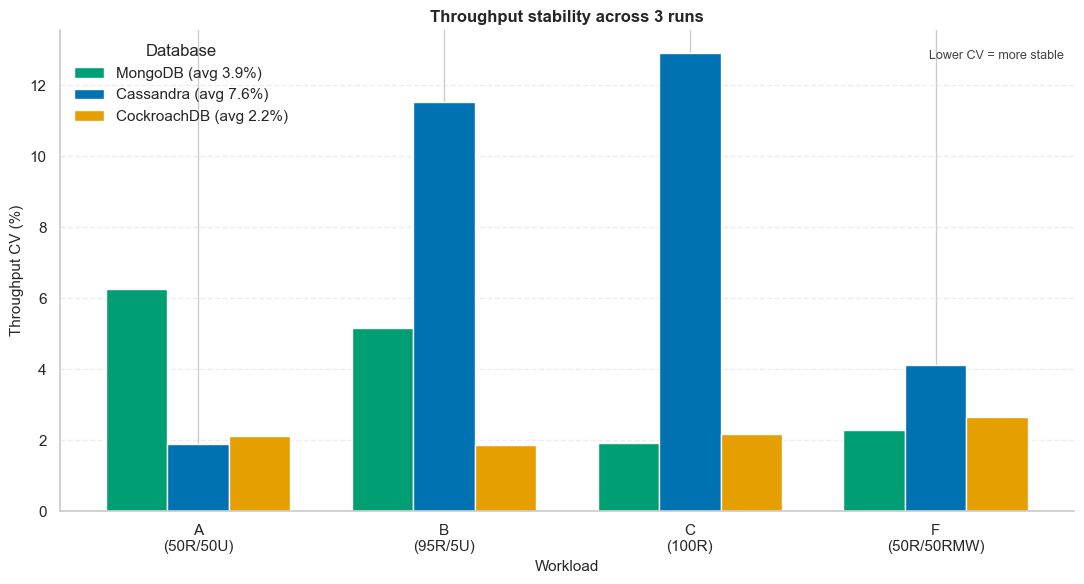

In [11]:
stability = mean_df.copy()
stability["throughput_cv_pct"] = stability["throughput_std"] / stability["throughput_ops_sec"] * 100

fig, ax = plt.subplots(figsize=(11, 6))
width = 0.25
x = list(range(len(WORKLOAD_ORDER)))

for i, db in enumerate(DB_ORDER):
    sub = db_slice(stability, db)
    vals = [sub.loc[w, "throughput_cv_pct"] for w in WORKLOAD_ORDER]
    avg_cv = sum(vals) / len(vals)
    offset = (i - 1) * width
    ax.bar([xi + offset for xi in x], vals, width, color=DB_COLORS[db], label=f"{DB_LABELS[db]} (avg {avg_cv:.1f}%)")

ax.set_xticks(x)
ax.set_xticklabels([WORKLOAD_LABELS[w] for w in WORKLOAD_ORDER])
ax.set_xlabel("Workload")
ax.set_ylabel("Throughput CV (%)")
ax.set_title("Throughput stability across 3 runs")
ax.legend(title="Database")
ax.text(0.99, 0.96, "Lower CV = more stable", transform=ax.transAxes, ha="right", va="top", fontsize=9, color="#444444")
finish_axis(ax)
fig.tight_layout()
save_figure(fig, "06_throughput_stability")
plt.show()


## Sanity Checks For Report


In [12]:
for db in DB_ORDER:
    events = parse_fault_events(db)
    timeline = parse_fault_log(db)
    if timeline.empty or not events:
        print(f"{DB_LABELS[db]:12s} (chua co fault log day du)")
        continue
    failed_updates = int(timeline["update_failed_count"].sum())
    print(
        f"{DB_LABELS[db]:12s} "
        f"STOP={events.get('node_stop')}s, "
        f"RECOVERY={events.get('node_recovery')}s, "
        f"END={events.get('benchmark_end')}s, "
        f"UPDATE-FAILED={failed_updates}"
    )

if not load_df.empty:
    display(load_df[[c for c in ["throughput_ops_sec", "insert_p95_us", "insert_p99_us", "insert_ok"] if c in load_df.columns]])


MongoDB      STOP=31.0s, RECOVERY=96.0s, END=997.0s, UPDATE-FAILED=0
Cassandra    STOP=31.0s, RECOVERY=93.0s, END=400.0s, UPDATE-FAILED=0
CockroachDB  STOP=31.0s, RECOVERY=93.0s, END=1145.0s, UPDATE-FAILED=2


,throughput_ops_sec,insert_p95_us,insert_p99_us,insert_ok
db,,,,
mongodb,1051.491541,31871.0,61631.0,1000000.0
cassandra,3941.461415,11375.0,37855.0,1000000.0
cockroachdb,1120.342735,27263.0,68479.0,1000000.0


## Display Saved Figures


01_throughput.png


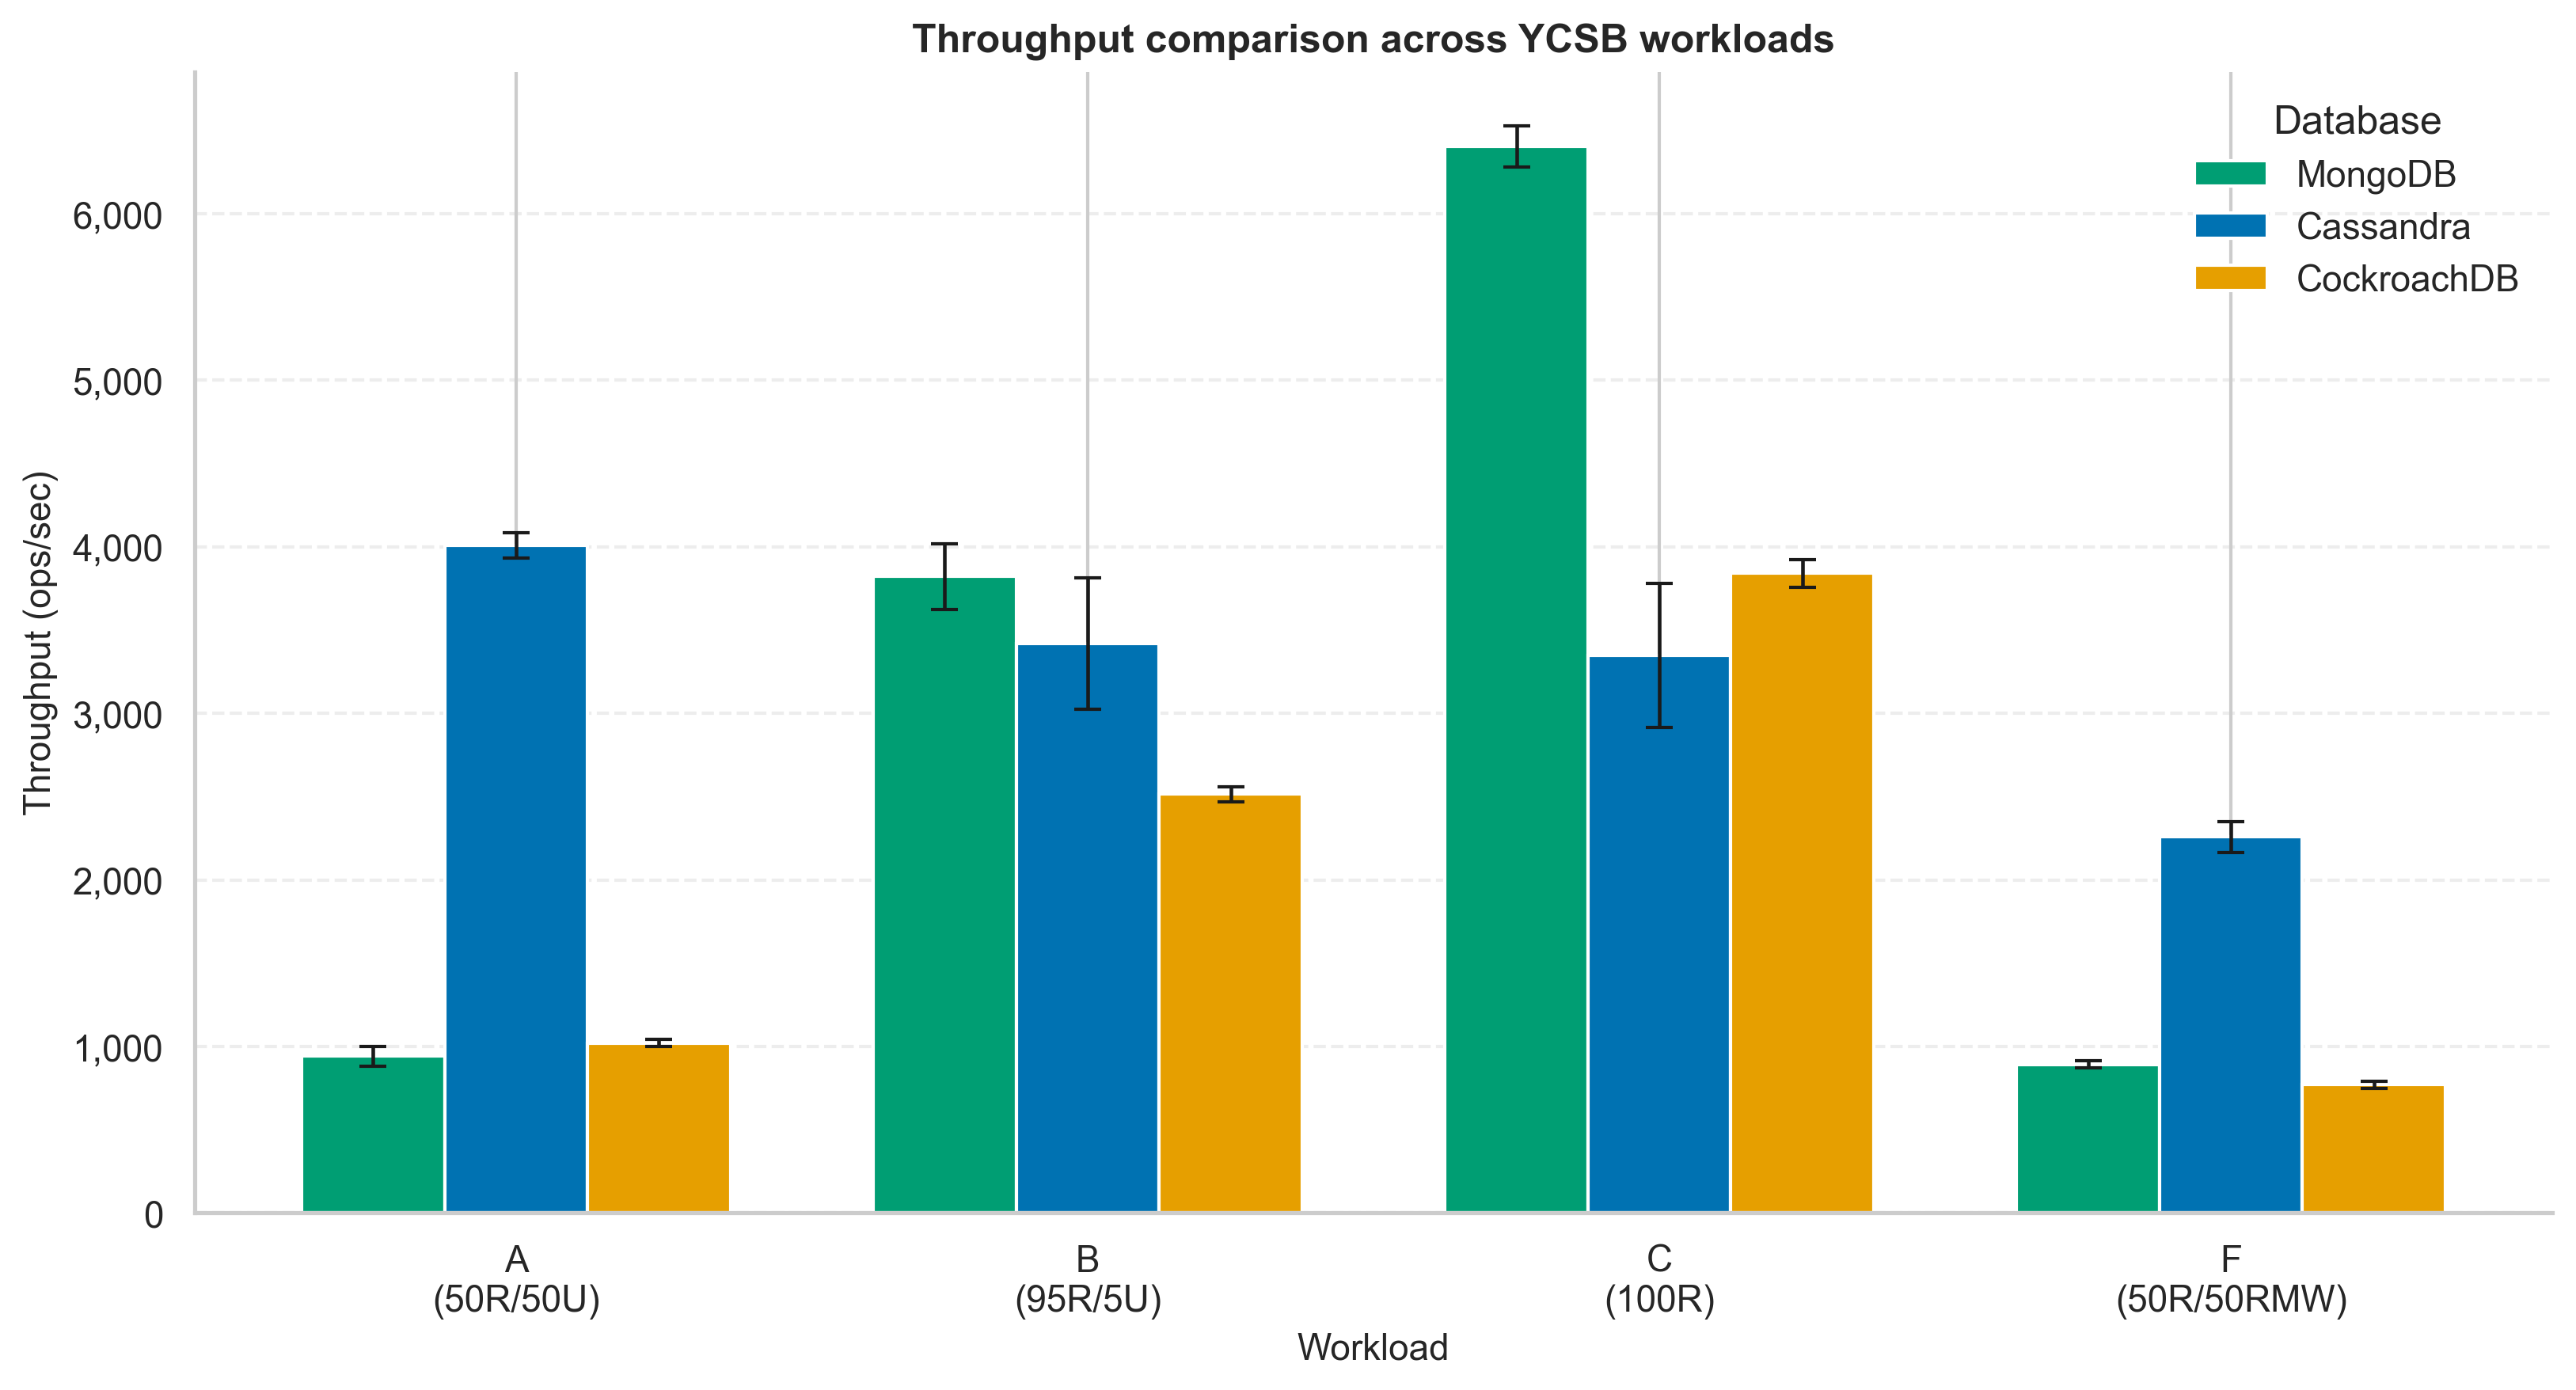

02_read_latency.png


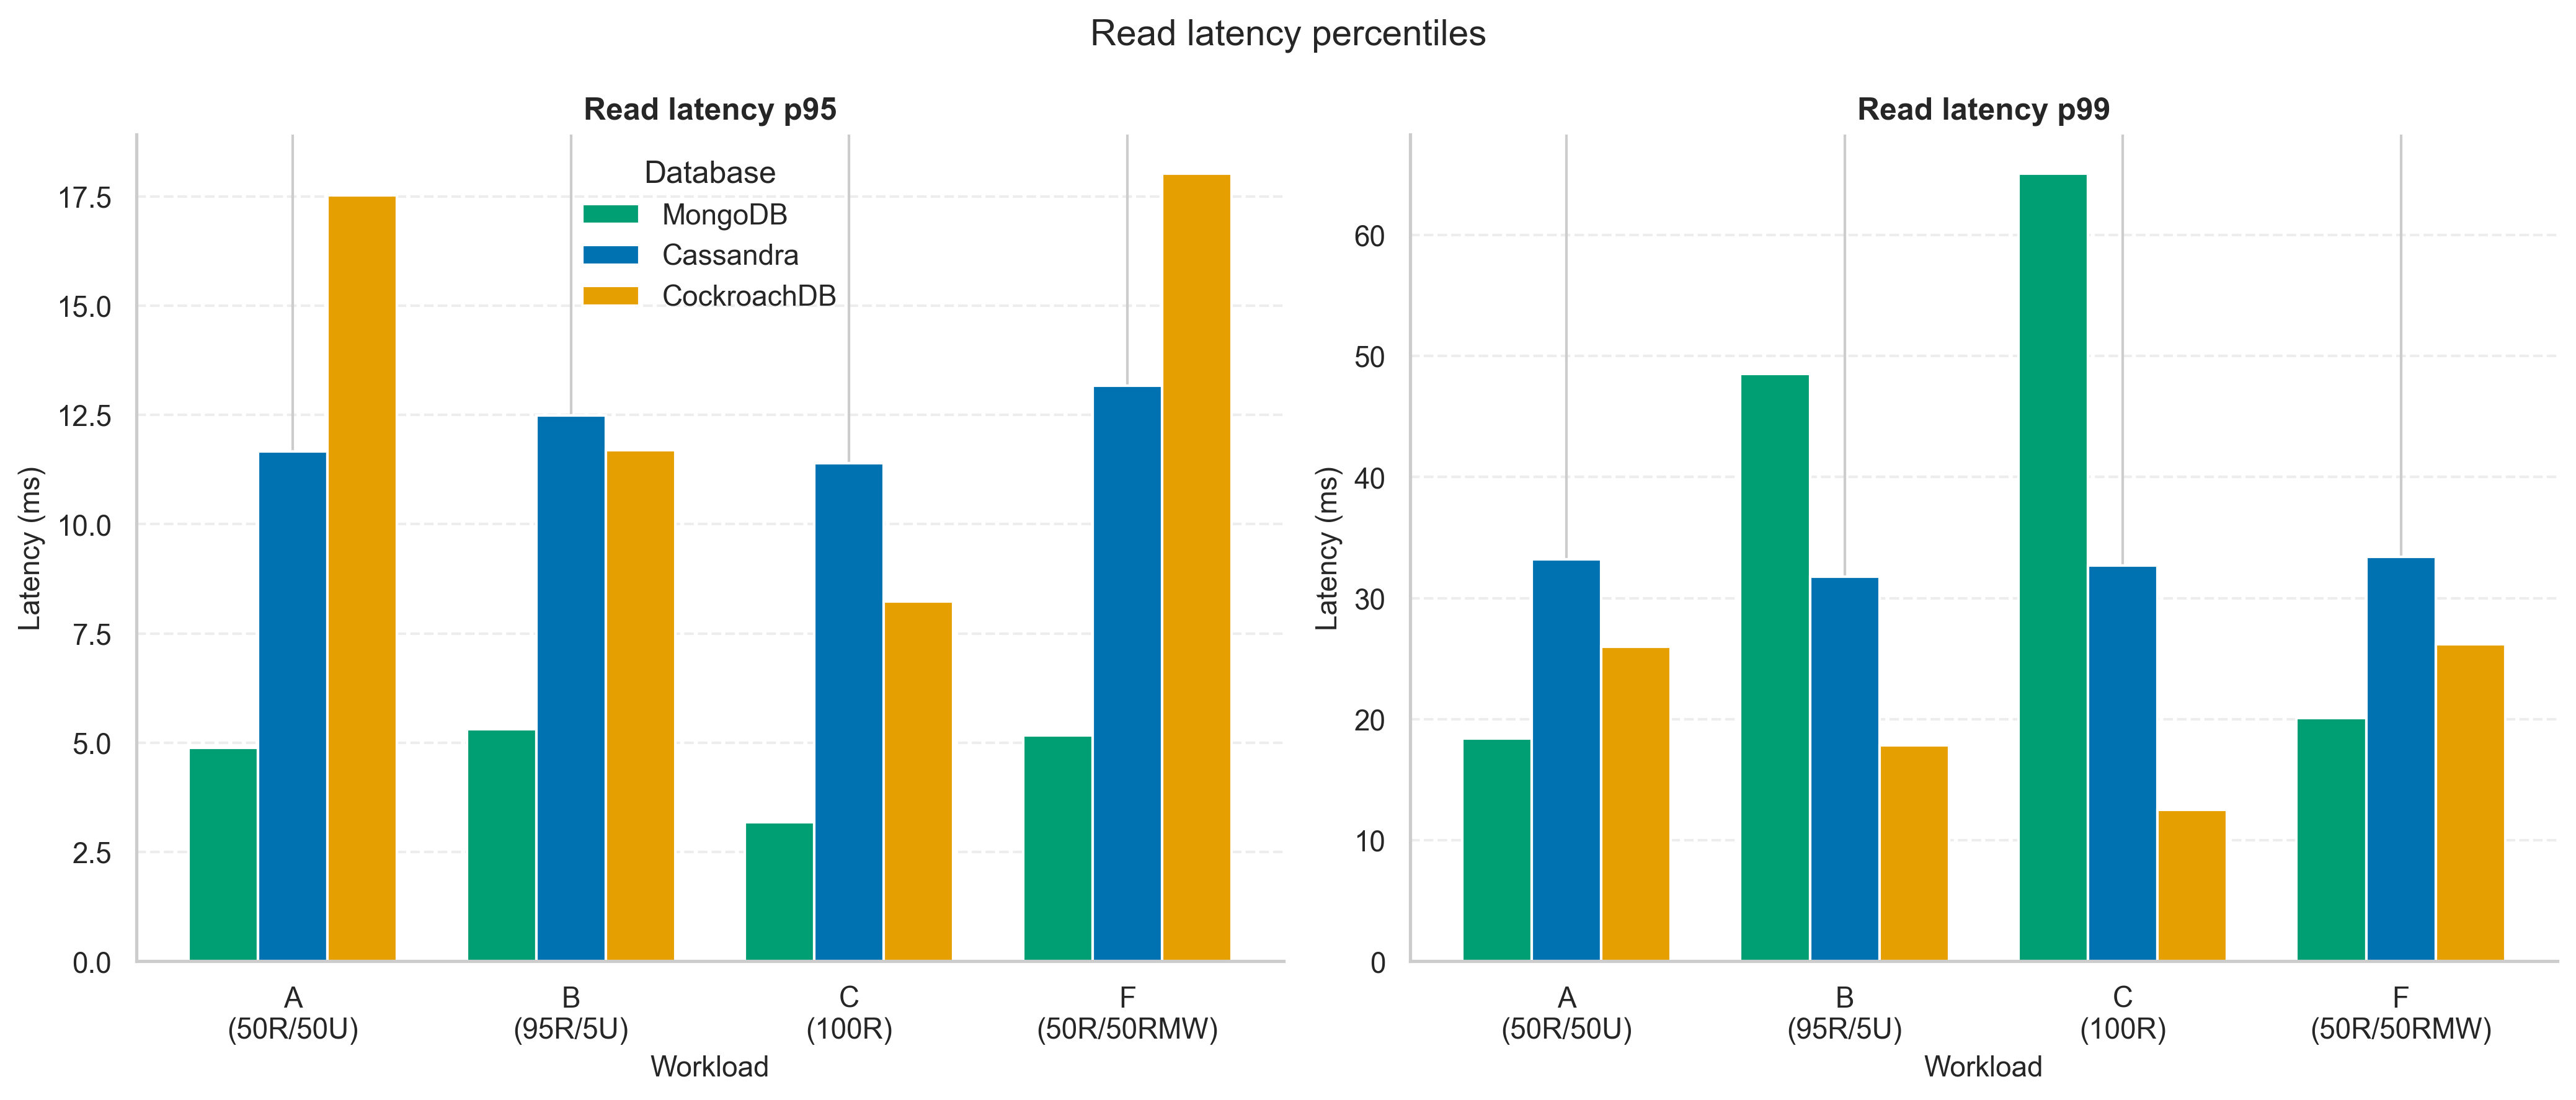

03_update_latency_p99.png


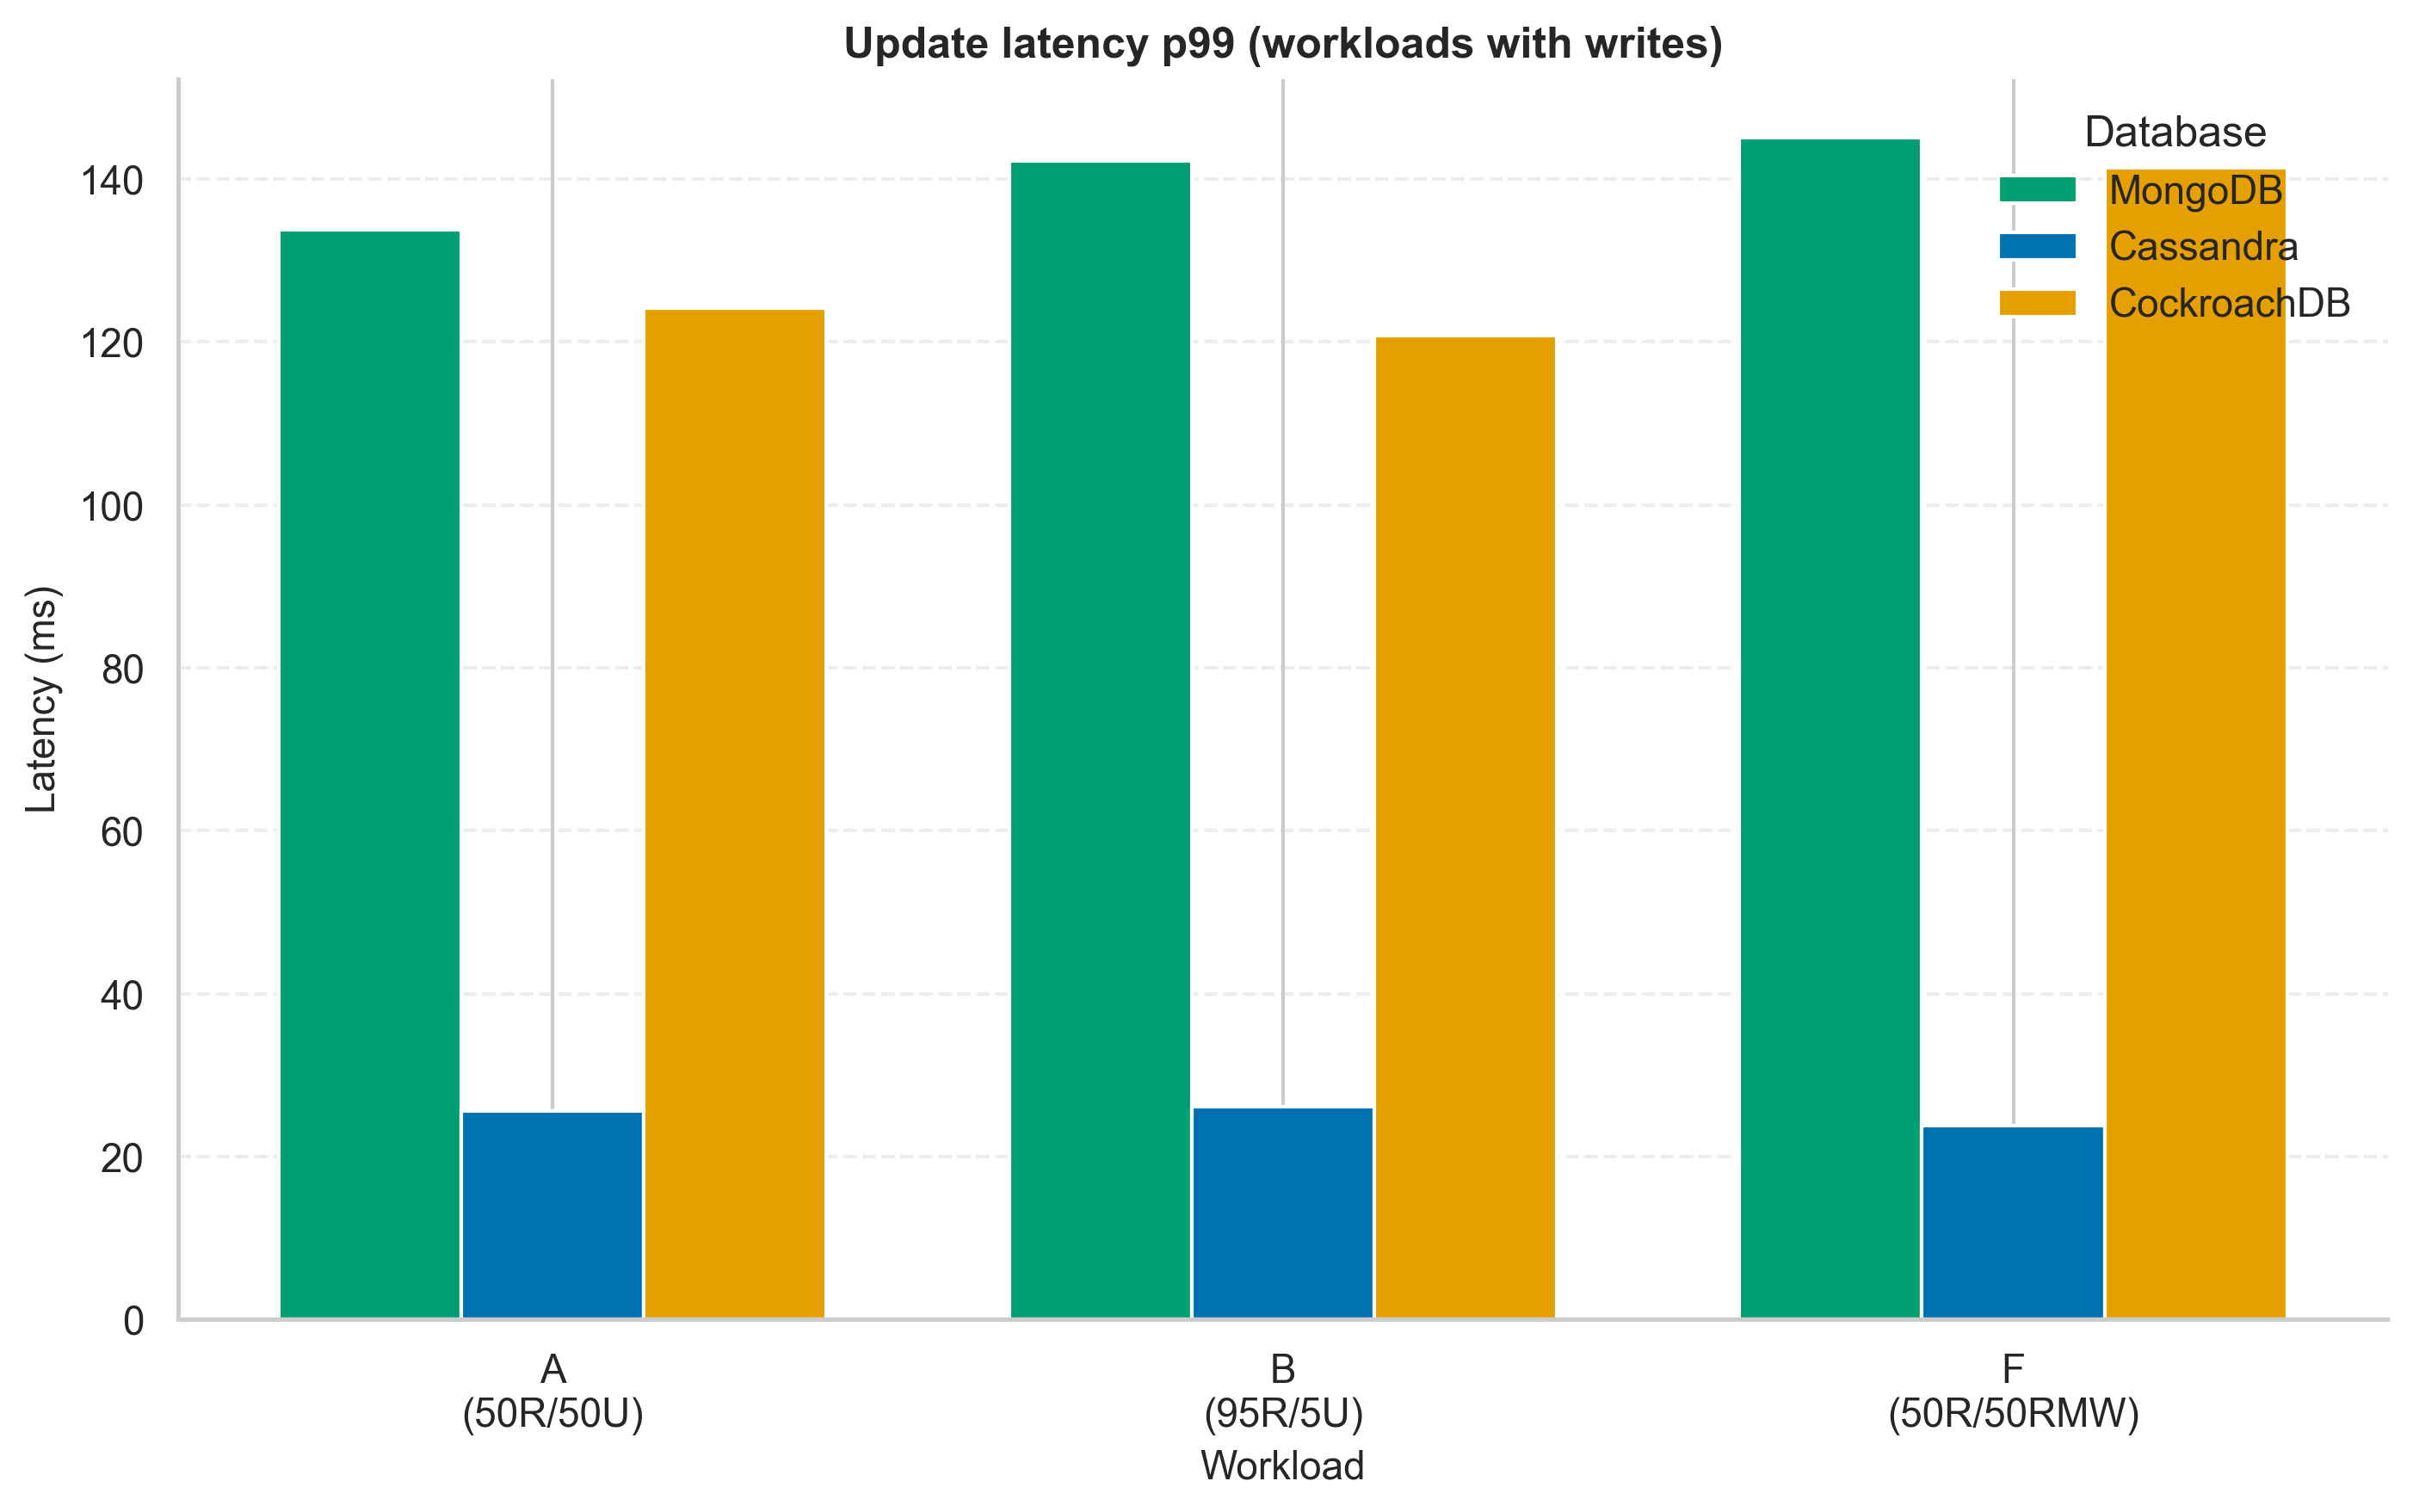

04_fault_tolerance.png


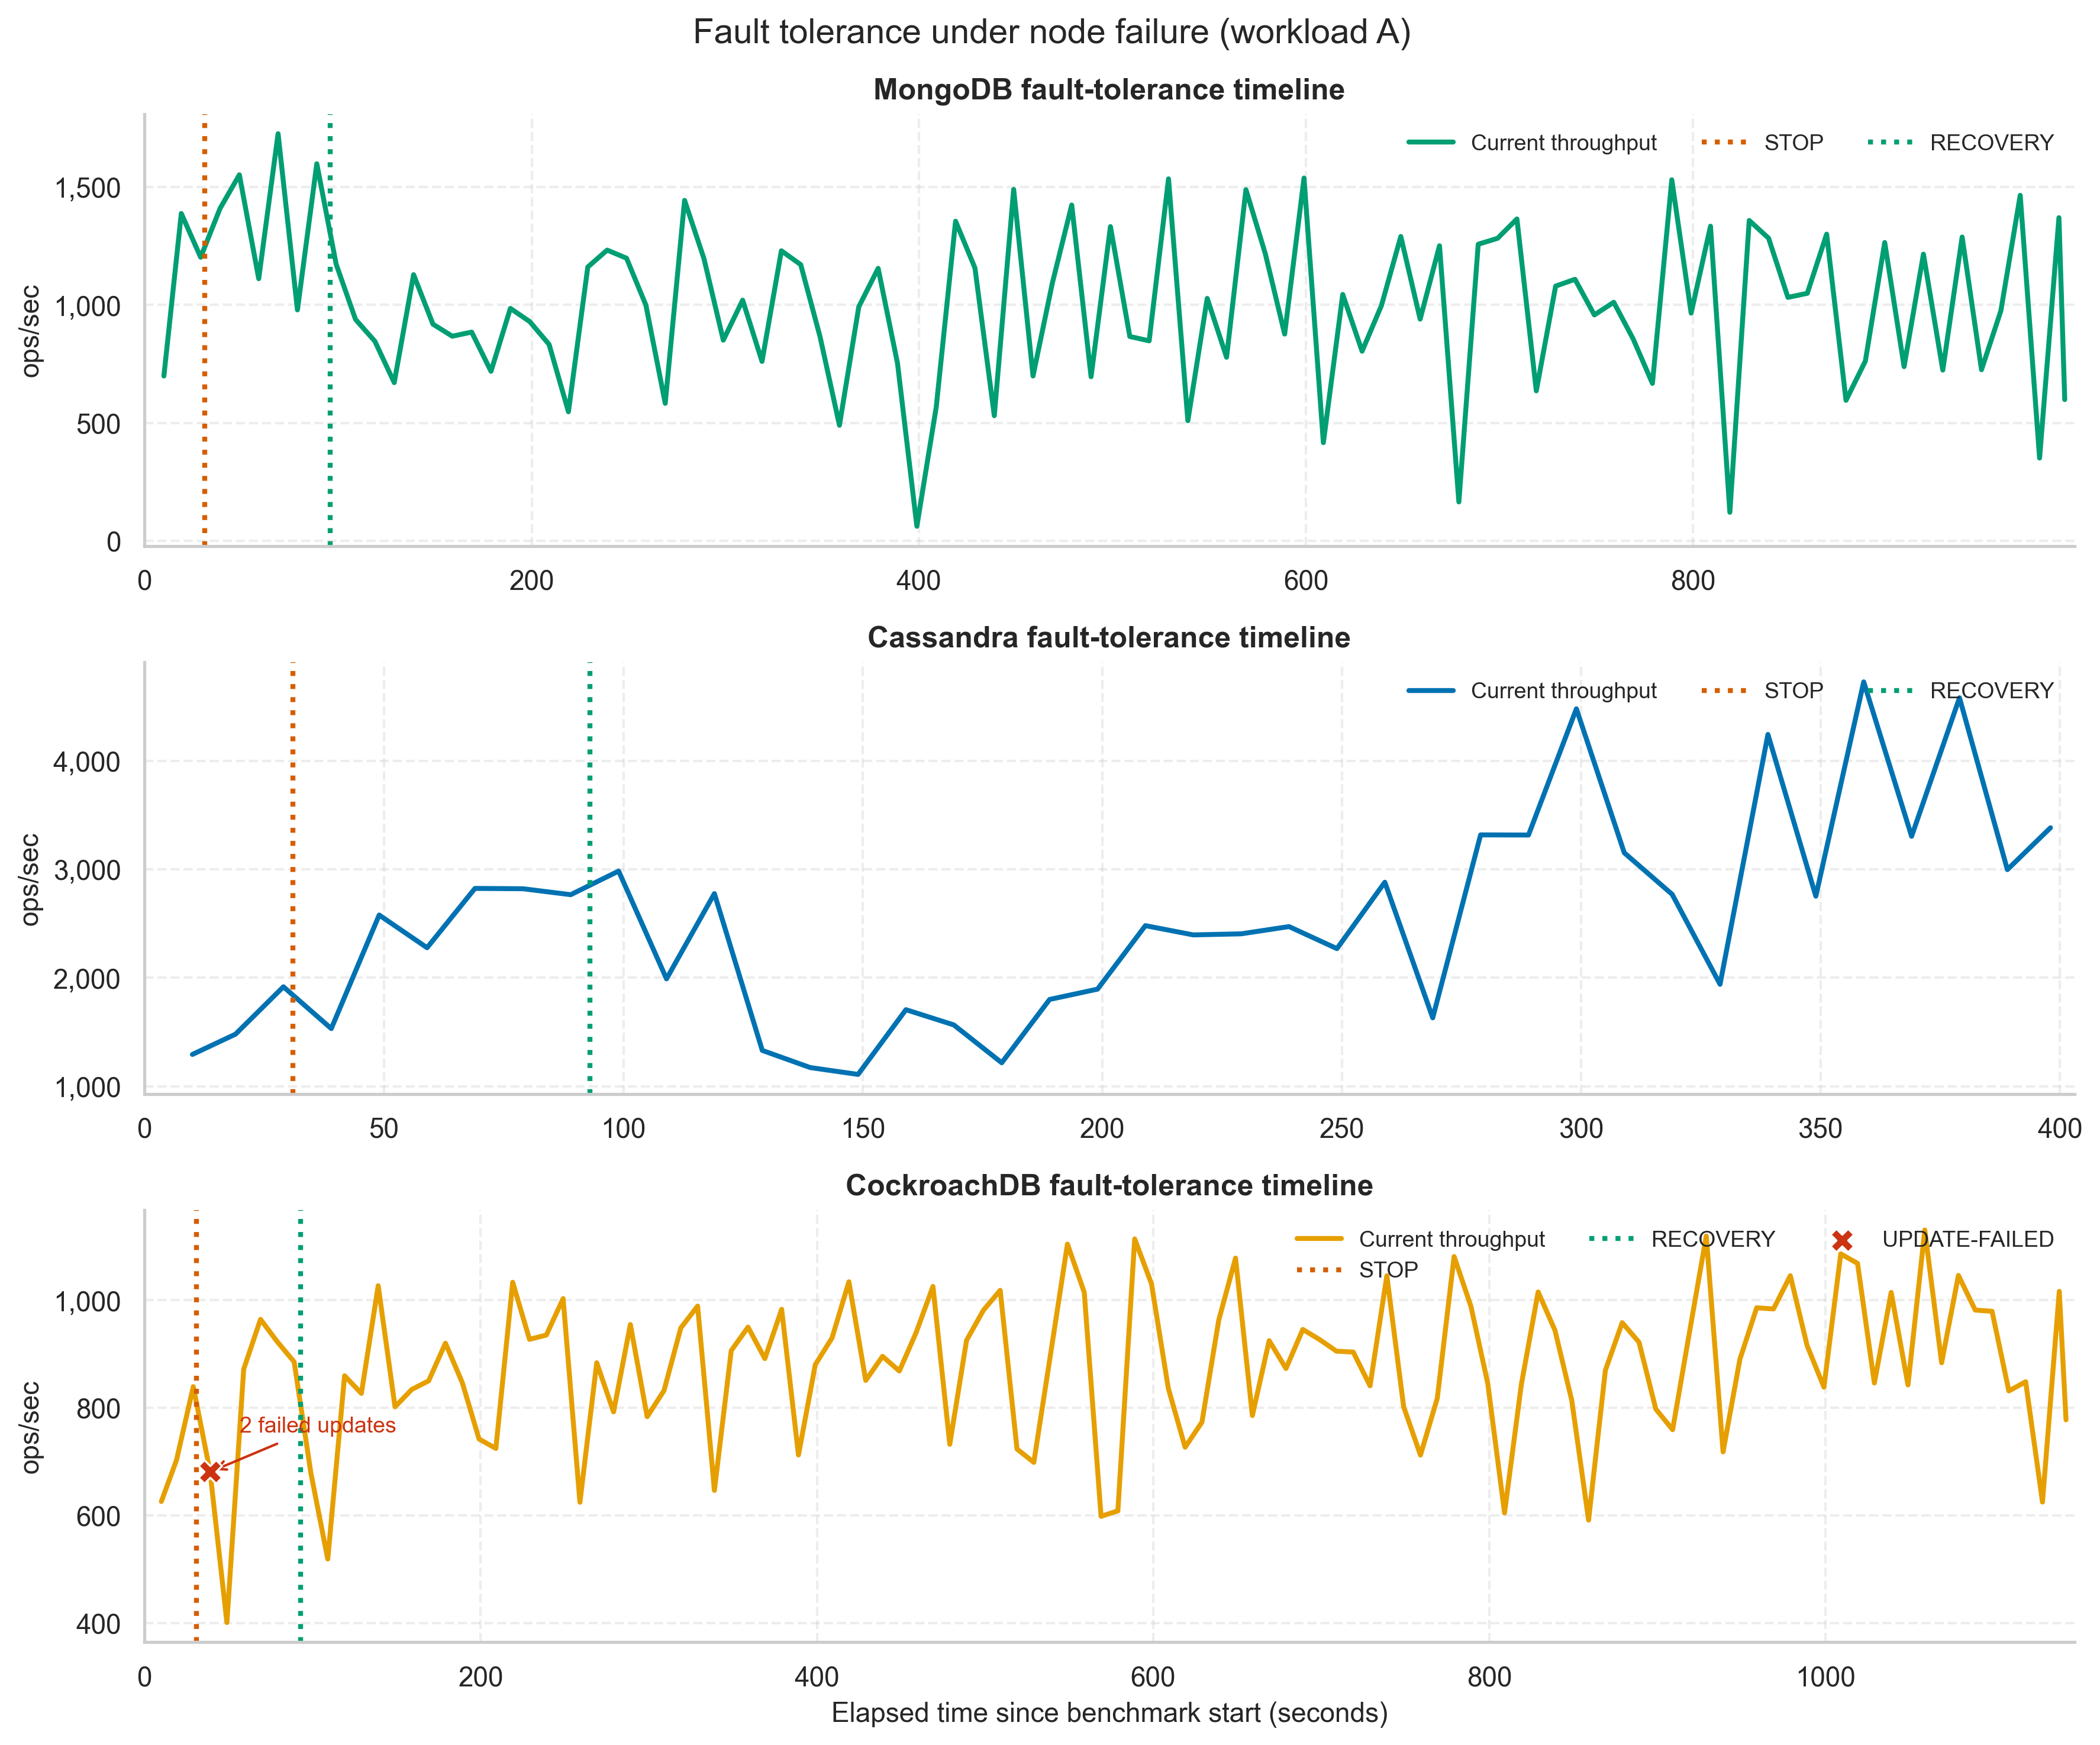

05_load_insert_latency.png


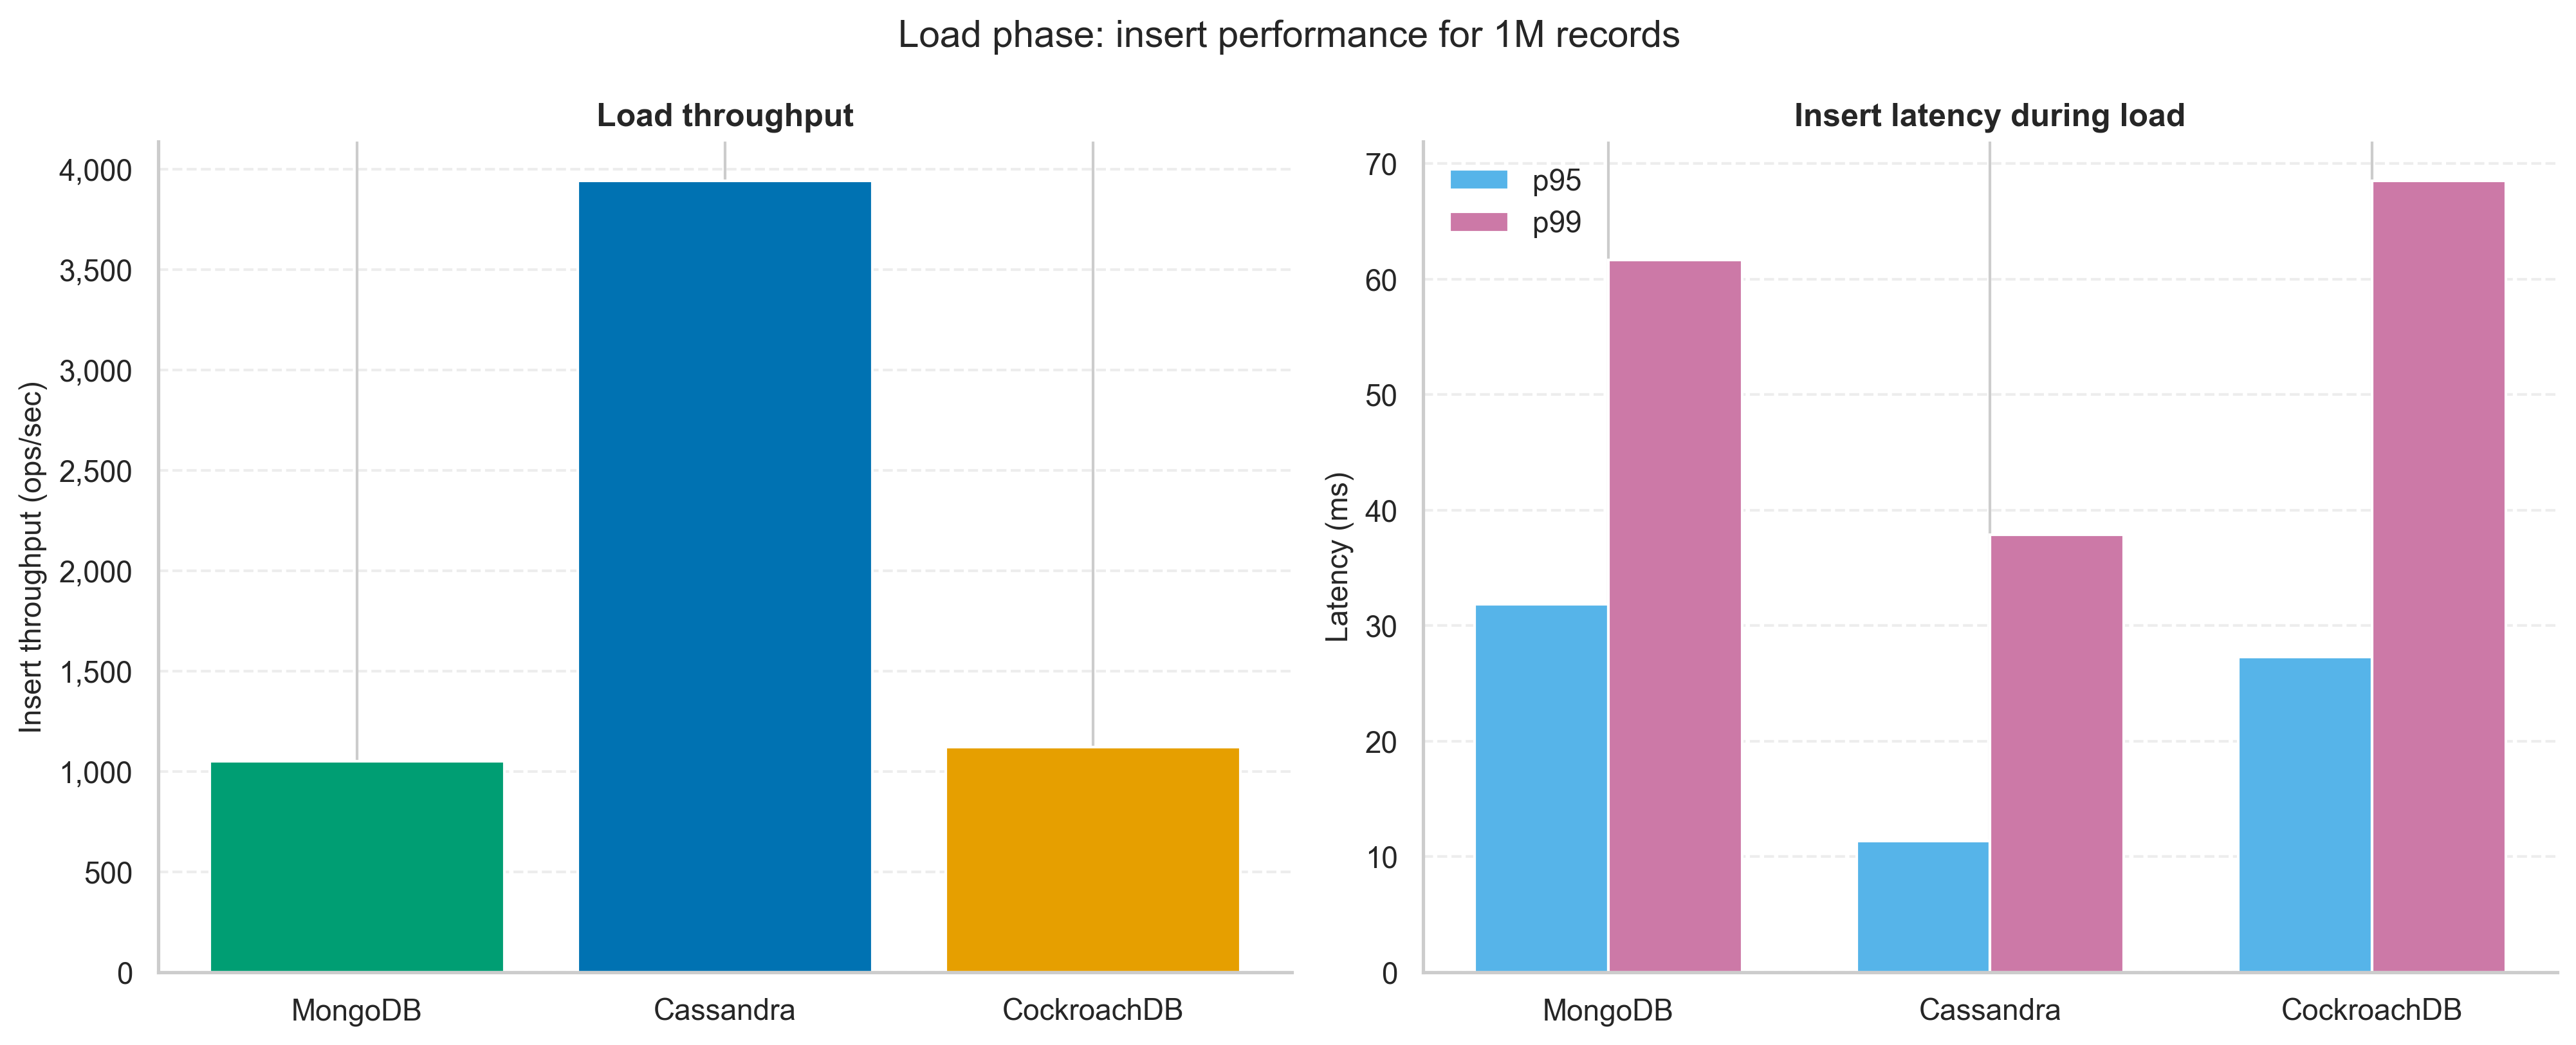

06_throughput_stability.png


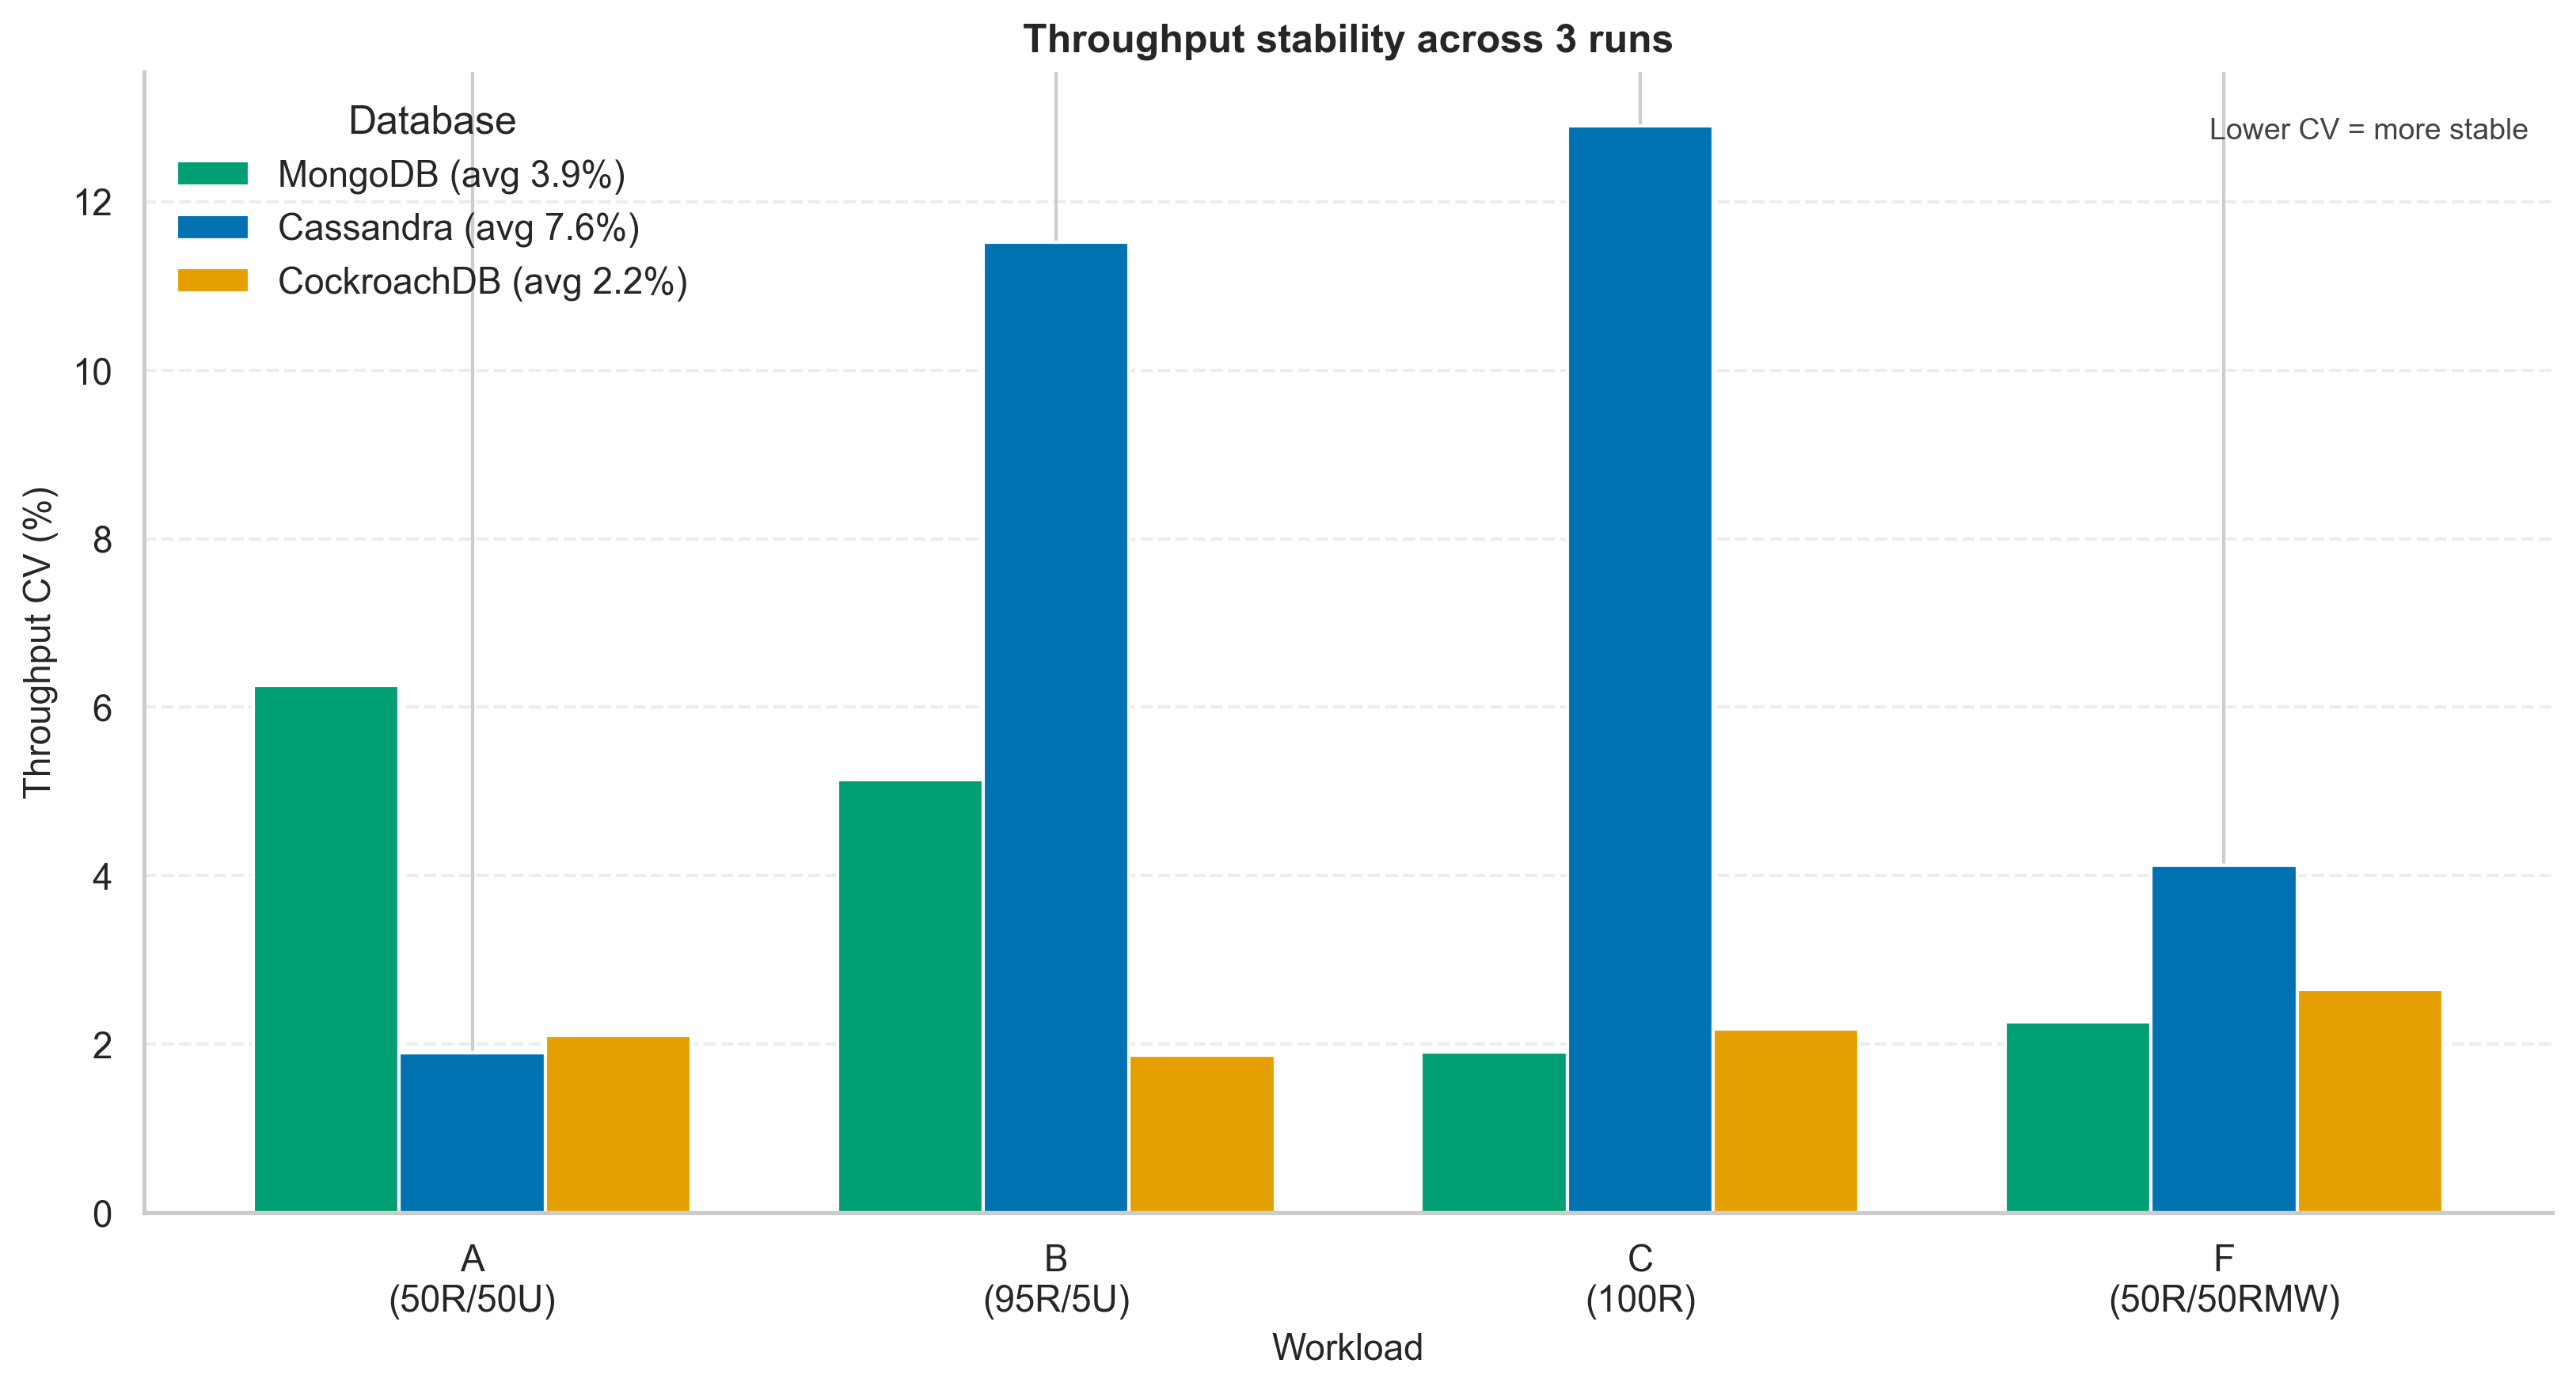

In [13]:
for stem in [
    "01_throughput",
    "02_read_latency",
    "03_update_latency_p99",
    "04_fault_tolerance",
    "05_load_insert_latency",
    "06_throughput_stability",
]:
    path = FIGURES_DIR / f"{stem}.png"
    print(path.name)
    display(Image(filename=str(path)))


## Đánh Giá Chi Tiết Biểu Đồ Và Việc Tiếp Theo

Phần này dùng để viết nhận xét cho Chương 4.4 và chuẩn bị slide bảo vệ. Mục tiêu không phải chỉ mô tả biểu đồ, mà là rút ra ý nghĩa hệ thống: database nào phù hợp workload nào, vì sao có peak hoặc đáy, và trade-off consistency/availability thể hiện ở đâu.

### Tóm tắt phát hiện quan trọng

| Chủ đề | Phát hiện chính | Số liệu nổi bật | Giải thích ngắn |
|---|---|---:|---|
| Peak throughput toàn bộ benchmark | MongoDB đạt đỉnh ở workload C | 6.405 ops/sec | Workload C là 100% read, phù hợp với document store + WiredTiger cache + index B-tree. |
| Workload ghi/mixed | Cassandra thắng rõ ở A và F | A: 4.011 ops/sec; F: 2.258 ops/sec | LSM-tree ghi tuần tự, tránh update tại chỗ; mô hình masterless giúp ghi phân tán tốt. |
| Workload read-heavy | MongoDB thắng B và C | B: 3.823 ops/sec; C: 6.405 ops/sec | Khi tỉ lệ đọc cao, cache và index của MongoDB phát huy mạnh. |
| Độ ổn định throughput | CockroachDB ổn định nhất | CV trung bình khoảng 2,2% | Raft + transaction làm throughput không cao nhất, nhưng biến thiên giữa 3 lần chạy thấp. |
| Fault tolerance | CockroachDB có lỗi update khi mất node | UPDATE-FAILED = 2 | CockroachDB ưu tiên consistency; khi Raft gặp ambiguous result thì hệ thống có thể fail operation thay vì ghi không chắc chắn. |

### 01_throughput - So sánh throughput

- Đây là biểu đồ chính nên đặt đầu phần kết quả. Nó cho thấy không có hệ nào thắng tuyệt đối; kết quả phụ thuộc vào workload.
- Peak cao nhất là MongoDB ở workload C, khoảng 6.405 ops/sec. Đây là workload 100% đọc, nên kết quả này củng cố nhận định MongoDB phù hợp read-heavy workload.
- Cassandra thắng workload A với khoảng 4.011 ops/sec, cao hơn MongoDB khoảng 4,26 lần và cao hơn CockroachDB khoảng 3,93 lần. Điều này rất rõ cho nhóm workload mixed 50% read / 50% update.
- Cassandra cũng thắng workload F với khoảng 2.258 ops/sec, cao hơn MongoDB khoảng 2,53 lần. Workload F có read-modify-write nên nặng hơn đọc thường, nhưng Cassandra vẫn có lợi thế nhờ write path dạng append-oriented của LSM-tree.
- MongoDB thắng workload B với khoảng 3.823 ops/sec, nhưng khoảng cách với Cassandra không quá lớn: chỉ khoảng 1,12 lần. Vì workload B vẫn còn 5% update nên Cassandra chưa bị bỏ xa.
- CockroachDB không thắng throughput ở workload nào. Đây không nên diễn giải là kém tuyệt đối, mà là chi phí của NewSQL: transaction, serializable isolation và Raft consensus làm mỗi ghi nặng hơn NoSQL.

### 02_read_latency - Read latency p95 và p99

- Biểu đồ này bổ sung cho throughput. Throughput cao không luôn đồng nghĩa tail latency thấp.
- MongoDB có read p99 tốt ở workload A và F: khoảng 18,40 ms ở A và 20,10 ms ở F. Điều này phù hợp với kết quả MongoDB xử lý đọc tốt.
- CockroachDB lại có read p99 thấp nhất ở workload B và C: khoảng 17,84 ms ở B và 12,51 ms ở C. Dù throughput không cao nhất, tail latency đọc của CockroachDB khá ổn định.
- MongoDB workload C có throughput cao nhất nhưng read p99 lại khoảng 65,06 ms, cao hơn Cassandra và CockroachDB. Điểm này cần giải thích cẩn thận: MongoDB xử lý tổng số operation rất nhanh, nhưng vẫn có một nhóm nhỏ request bị tail latency cao, có thể do cache/flush/GC hoặc nhiễu tài nguyên trên Docker Desktop.
- Cassandra read p99 thường nằm khoảng 31-33 ms, không phải tốt nhất về read latency. Điều này hợp lý vì Cassandra tối ưu write path hơn read path; đọc có thể phải đi qua memtable/SSTable và reconciliation tùy dữ liệu.

### 03_update_latency_p99 - Update latency p99

- Đây là biểu đồ rất mạnh để giải thích vì sao Cassandra thắng các workload có ghi.
- Cassandra có update p99 thấp nhất ở cả A, B và F: khoảng 25,62 ms ở A, 26,11 ms ở B và 23,85 ms ở F.
- MongoDB và CockroachDB có update p99 cao hơn nhiều, thường khoảng 120-145 ms. MongoDB dùng writeConcern majority nên update cần đảm bảo replication; CockroachDB dùng transaction + Raft nên mỗi ghi có thêm overhead đồng thuận.
- Workload C bị loại khỏi biểu đồ là đúng, vì C là 100% read nên không có update latency để so sánh.

### 04_fault_tolerance - Timeline chịu lỗi

- Đây là biểu đồ quan trọng nhất cho phần CAP trade-off. Việc tách thành 3 subplot là đúng vì thời lượng benchmark khác nhau: Cassandra kết thúc khoảng 400 giây, MongoDB khoảng 997 giây, CockroachDB khoảng 1.145 giây.
- Mốc STOP nằm khoảng 31 giây cho cả 3 hệ; mốc RECOVERY khoảng 93-96 giây. Vì vậy mỗi subplot phải dùng mốc riêng đọc từ event log, không nên dùng một cặp vạch dọc chung cho toàn biểu đồ.
- Cassandra không có operation fail, đáy throughput theo log khoảng 1.109,9 ops/sec và peak khoảng 4.726,4 ops/sec. Đây là hành vi nghiêng AP: hệ thống vẫn phục vụ khi mất một node nhờ RF=3 và consistency level hiện tại chấp nhận tiếp tục trả lời.
- MongoDB cũng không có operation fail khi dừng secondary. Peak theo log khoảng 1.725,2 ops/sec. Có một số tụt sâu trong timeline, nhưng không đi kèm failed operation; nên diễn giải là dao động/tail stall trong môi trường Docker hơn là mất availability.
- CockroachDB có 2 UPDATE-FAILED ngay sau khi node bị dừng. Đáy throughput khoảng 401,5 ops/sec ở giai đoạn fault, sau đó phục hồi dần. Đây là bằng chứng thực nghiệm cho CP strict: hệ thống ưu tiên nhất quán, có thể trả lỗi khi kết quả ghi bị ambiguous thay vì chấp nhận ghi không chắc chắn.

### 05_load_insert_latency - Load phase / insert performance

- Biểu đồ này nên đưa vào báo cáo vì nó tách riêng năng lực ghi thuần lúc load 1 triệu records, không bị pha trộn với đọc như workload A/F.
- Cassandra load throughput khoảng 3.941 ops/sec, cao hơn MongoDB khoảng 3,75 lần và cao hơn CockroachDB khoảng 3,52 lần.
- Cassandra cũng có insert latency thấp nhất: p95 khoảng 11,38 ms và p99 khoảng 37,86 ms. MongoDB p99 khoảng 61,63 ms, CockroachDB p99 khoảng 68,48 ms.
- Đây là bằng chứng trực tiếp cho luận điểm Cassandra phù hợp write-heavy workload nhờ LSM-tree và mô hình phân tán masterless.

### 06_throughput_stability - Độ ổn định throughput

- CV càng thấp thì throughput càng ổn định giữa 3 lần chạy.
- CockroachDB có CV trung bình thấp nhất, khoảng 2,2%. Đây là điểm mạnh cần nhấn mạnh: dù throughput không cao nhất, kết quả của CockroachDB ít dao động.
- MongoDB CV trung bình khoảng 3,9%, tương đối ổn.
- Cassandra CV trung bình khoảng 7,6%, cao nhất. Điều này không phủ định throughput cao của Cassandra; nó cho thấy Cassandra nhanh nhưng nhạy hơn với trạng thái tài nguyên, compaction, JVM/GC hoặc nhiễu Docker ở một số workload.

### Cách viết kết luận cho Chương 4.4

- Nếu ứng dụng thiên về ghi nhiều, ingest log, event stream hoặc workload mixed có update thường xuyên, Cassandra là lựa chọn mạnh nhất trong thí nghiệm này.
- Nếu ứng dụng thiên về đọc nhiều và cần throughput đọc cao, MongoDB có lợi thế rõ, đặc biệt ở workload C.
- Nếu ứng dụng cần SQL phân tán, ACID và consistency mạnh, CockroachDB đánh đổi throughput để lấy tính nhất quán và độ ổn định.
- Kết quả fault tolerance cho thấy khác biệt CAP rõ ràng: Cassandra nghiêng AP, CockroachDB nghiêng CP nghiêm ngặt, MongoDB CP-leaning trong kịch bản dừng secondary.

### Việc tiếp theo cần làm

1. Chèn 6 hình PNG vào báo cáo, ưu tiên thứ tự: 01_throughput, 03_update_latency_p99, 05_load_insert_latency, 06_throughput_stability, 04_fault_tolerance, 02_read_latency.
2. Viết caption cho từng hình, trong caption phải ghi đơn vị: throughput là ops/sec, latency là ms, dữ liệu là trung bình 3 runs nếu dùng summary_mean.
3. Viết Chương 4.4 theo mạch: throughput tổng quan -> latency đọc/ghi -> load phase -> stability -> fault tolerance/CAP.
4. Thêm một bảng tổng hợp nhỏ cuối Chương 4.4: DB mạnh nhất cho read-heavy, write-heavy, stability và fault behavior.
5. Nêu hạn chế thí nghiệm: chạy trên một máy Docker Desktop, không phải multi-host cluster thật; mỗi cấu hình chạy 3 lần; workload là synthetic benchmark YCSB; chưa tuning sâu từng DB.
6. Khi bảo vệ, nhấn mạnh kết luận quan trọng nhất: không có database tốt nhất tuyệt đối, chỉ có database phù hợp nhất với workload và yêu cầu consistency/availability cụ thể.
